In [1]:
import os

base = r'C:\Users\{YOUR_USERNAME}\Downloads\FDA-FAERS analysis'
# We'll auto-detect the username:
base = os.path.join(os.path.expanduser('~'), 'Downloads', 'FDA-FAERS analysis')

quarters = ['faers_ascii_2025q1', 'faers_ascii_2025q2', 
            'faers_ascii_2025q3', 'faers_ascii_2025Q4']

for q in quarters:
    path = os.path.join(base, q)
    if os.path.exists(path):
        files = os.listdir(path)
        print(f"\n📁 {q}:")
        for f in sorted(files):
            print(f"   {f}")
    else:
        print(f"❌ Not found: {path}")


📁 faers_ascii_2025q1:
   ASCII
   Deleted
   FAQs.pdf
   Readme.pdf

📁 faers_ascii_2025q2:
   ASCII
   Deleted
   FAQs.pdf
   Readme.pdf

📁 faers_ascii_2025q3:
   ASCII
   Deleted
   FAQs.pdf
   Readme.pdf

📁 faers_ascii_2025Q4:
   ASCII
   Deleted
   FAQs.pdf
   Readme.pdf


In [2]:
for q in quarters:
    path = os.path.join(base, q, 'ASCII')
    if os.path.exists(path):
        files = os.listdir(path)
        print(f"\n📁 {q}/ASCII:")
        for f in sorted(files):
            print(f"   {f}")


📁 faers_ascii_2025q1/ASCII:
   ASC_NTS.pdf
   DEMO25Q1.pdf
   DEMO25Q1.txt
   DRUG25Q1.pdf
   DRUG25Q1.txt
   INDI25Q1.pdf
   INDI25Q1.txt
   OUTC25Q1.pdf
   OUTC25Q1.txt
   REAC25Q1.pdf
   REAC25Q1.txt
   RPSR25Q1.pdf
   RPSR25Q1.txt
   THER25Q1.pdf
   THER25Q1.txt

📁 faers_ascii_2025q2/ASCII:
   ASC_NTS.pdf
   DEMO25Q2.pdf
   DEMO25Q2.txt
   DRUG25Q2.pdf
   DRUG25Q2.txt
   INDI25Q2.pdf
   INDI25Q2.txt
   OUTC25Q2.pdf
   OUTC25Q2.txt
   REAC25Q2.pdf
   REAC25Q2.txt
   RPSR25Q2.pdf
   RPSR25Q2.txt
   THER25Q2.pdf
   THER25Q2.txt

📁 faers_ascii_2025q3/ASCII:
   ASC_NTS.pdf
   DEMO25Q3.pdf
   DEMO25Q3.txt
   DRUG25Q3.pdf
   DRUG25Q3.txt
   INDI25Q3.pdf
   INDI25Q3.txt
   OUTC25Q3.pdf
   OUTC25Q3.txt
   REAC25Q3.pdf
   REAC25Q3.txt
   RPSR25Q3.pdf
   RPSR25Q3.txt
   THER25Q3.pdf
   THER25Q3.txt

📁 faers_ascii_2025Q4/ASCII:
   ASC_NTS.pdf
   DEMO25Q4.pdf
   DEMO25Q4.txt
   DRUG25Q4.pdf
   DRUG25Q4.txt
   INDI25Q4.pdf
   INDI25Q4.txt
   OUTC25Q4.pdf
   OUTC25Q4.txt
   REAC25Q4.pdf
   REAC2

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

base = os.path.join(os.path.expanduser('~'), 'Downloads', 'FDA-FAERS analysis')

# Map folder name → file suffix
quarter_map = {
    'faers_ascii_2025q1': '25Q1',
    'faers_ascii_2025q2': '25Q2',
    'faers_ascii_2025q3': '25Q3',
    'faers_ascii_2025Q4': '25Q4',
}

demo_list, drug_list, reac_list, outc_list = [], [], [], []

for folder, suffix in quarter_map.items():
    path = os.path.join(base, folder, 'ASCII')
    try:
        demo = pd.read_csv(os.path.join(path, f'DEMO{suffix}.txt'), sep='$', encoding='latin1', low_memory=False)
        drug = pd.read_csv(os.path.join(path, f'DRUG{suffix}.txt'), sep='$', encoding='latin1', low_memory=False)
        reac = pd.read_csv(os.path.join(path, f'REAC{suffix}.txt'), sep='$', encoding='latin1', low_memory=False)
        outc = pd.read_csv(os.path.join(path, f'OUTC{suffix}.txt'), sep='$', encoding='latin1', low_memory=False)

        for df in [demo, drug, reac, outc]:
            df['quarter'] = suffix

        demo_list.append(demo); drug_list.append(drug)
        reac_list.append(reac); outc_list.append(outc)

        print(f"✅ {suffix} — DEMO:{len(demo):,}  DRUG:{len(drug):,}  REAC:{len(reac):,}  OUTC:{len(outc):,}")

    except Exception as e:
        print(f"❌ {suffix} error: {e}")

# Combine
demo_all = pd.concat(demo_list, ignore_index=True)
drug_all = pd.concat(drug_list, ignore_index=True)
reac_all = pd.concat(reac_list, ignore_index=True)
outc_all = pd.concat(outc_list, ignore_index=True)

print(f"\n📊 COMBINED TOTALS:")
print(f"   DEMO : {len(demo_all):,}")
print(f"   DRUG : {len(drug_all):,}")
print(f"   REAC : {len(reac_all):,}")
print(f"   OUTC : {len(outc_all):,}")

✅ 25Q1 — DEMO:400,514  DRUG:2,008,162  REAC:1,432,926  OUTC:304,027
✅ 25Q2 — DEMO:393,130  DRUG:1,829,056  REAC:1,340,666  OUTC:295,583
✅ 25Q3 — DEMO:438,512  DRUG:2,148,451  REAC:1,535,133  OUTC:343,251
✅ 25Q4 — DEMO:385,288  DRUG:1,815,349  REAC:1,349,105  OUTC:289,721

📊 COMBINED TOTALS:
   DEMO : 1,617,444
   DRUG : 7,801,018
   REAC : 5,657,830
   OUTC : 1,232,582


In [4]:
# Keep only latest version of each case
demo_all = demo_all.sort_values('caseversion', ascending=False)
demo_all = demo_all.drop_duplicates(subset='primaryid', keep='first')

# Standardize drug names
drug_all['drugname'] = drug_all['drugname'].str.upper().str.strip()

# Keep only Primary Suspect drugs
drug_ps = drug_all[drug_all['role_cod'] == 'PS'].copy()

# Standardize reaction terms
reac_all['pt'] = reac_all['pt'].str.upper().str.strip()

print(f"✅ After dedup — Unique cases : {len(demo_all):,}")
print(f"✅ Primary Suspect drug records: {len(drug_ps):,}")
print(f"✅ Unique drugs  : {drug_ps['drugname'].nunique():,}")
print(f"✅ Unique ADEs   : {reac_all['pt'].nunique():,}")

✅ After dedup — Unique cases : 1,617,313
✅ Primary Suspect drug records: 1,778,207
✅ Unique drugs  : 6,728
✅ Unique ADEs   : 16,794


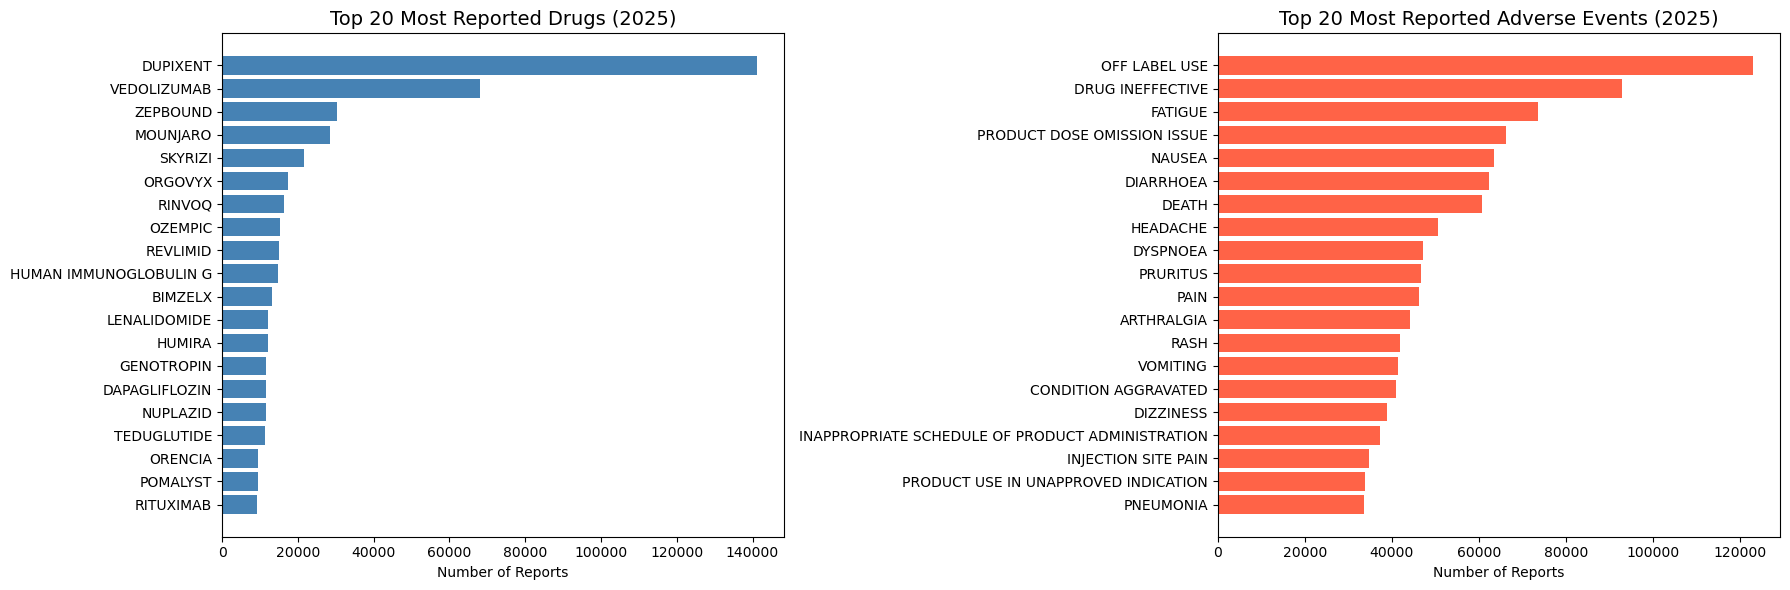

✅ Plot saved!


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Top 20 drugs
top_drugs = drug_ps['drugname'].value_counts().head(20)
axes[0].barh(top_drugs.index[::-1], top_drugs.values[::-1], color='steelblue')
axes[0].set_title('Top 20 Most Reported Drugs (2025)', fontsize=14)
axes[0].set_xlabel('Number of Reports')

# Top 20 adverse events
top_reac = reac_all['pt'].value_counts().head(20)
axes[1].barh(top_reac.index[::-1], top_reac.values[::-1], color='tomato')
axes[1].set_title('Top 20 Most Reported Adverse Events (2025)', fontsize=14)
axes[1].set_xlabel('Number of Reports')

plt.tight_layout()
plt.savefig('top_drugs_reactions.png', dpi=150)
plt.show()
print("✅ Plot saved!")

In [6]:
# Define all GLP-1 brand/generic names
glp1_names = [
    'OZEMPIC', 'WEGOVY', 'RYBELSUS', 'SEMAGLUTIDE',
    'MOUNJARO', 'ZEPBOUND', 'TIRZEPATIDE'
]

# Filter primary suspect drugs for GLP-1s
glp1_drugs = drug_ps[drug_ps['drugname'].isin(glp1_names)].copy()

# Add drug group label
sema = ['OZEMPIC', 'WEGOVY', 'RYBELSUS', 'SEMAGLUTIDE']
tirz = ['MOUNJARO', 'ZEPBOUND', 'TIRZEPATIDE']

glp1_drugs['drug_group'] = glp1_drugs['drugname'].apply(
    lambda x: 'Semaglutide' if x in sema else 'Tirzepatide'
)

print("📊 GLP-1 Report Counts:")
print(glp1_drugs['drugname'].value_counts())
print(f"\n📊 By Group:")
print(glp1_drugs['drug_group'].value_counts())
print(f"\n✅ Total GLP-1 primary suspect cases: {glp1_drugs['primaryid'].nunique():,}")

📊 GLP-1 Report Counts:
drugname
ZEPBOUND       30346
MOUNJARO       28405
OZEMPIC        15311
WEGOVY          5413
RYBELSUS        1160
TIRZEPATIDE      970
SEMAGLUTIDE      958
Name: count, dtype: int64

📊 By Group:
drug_group
Tirzepatide    59721
Semaglutide    22842
Name: count, dtype: int64

✅ Total GLP-1 primary suspect cases: 82,558


In [7]:
# Get primaryids of all GLP-1 cases
glp1_ids = glp1_drugs['primaryid'].unique()

# Filter reactions and outcomes for these cases only
glp1_reac = reac_all[reac_all['primaryid'].isin(glp1_ids)].copy()
glp1_outc = outc_all[outc_all['primaryid'].isin(glp1_ids)].copy()

# Merge drug group info into reactions
glp1_reac = glp1_reac.merge(
    glp1_drugs[['primaryid', 'drug_group', 'drugname']].drop_duplicates('primaryid'),
    on='primaryid', how='left'
)

print(f"✅ GLP-1 adverse event records : {len(glp1_reac):,}")
print(f"✅ GLP-1 outcome records        : {len(glp1_outc):,}")
print(f"\n📊 Top 20 ADEs for ALL GLP-1 drugs:")
print(glp1_reac['pt'].value_counts().head(20))

✅ GLP-1 adverse event records : 194,868
✅ GLP-1 outcome records        : 31,270

📊 Top 20 ADEs for ALL GLP-1 drugs:
pt
INCORRECT DOSE ADMINISTERED                 11790
NAUSEA                                       9132
DIARRHOEA                                    5468
VOMITING                                     5277
INJECTION SITE PAIN                          5006
OFF LABEL USE                                4650
CONSTIPATION                                 4076
EXTRA DOSE ADMINISTERED                      4057
DRUG INEFFECTIVE                             2959
DECREASED APPETITE                           2672
IMPAIRED GASTRIC EMPTYING                    2518
FATIGUE                                      2361
WEIGHT INCREASED                             2304
ABDOMINAL PAIN UPPER                         2295
ACCIDENTAL UNDERDOSE                         2224
PRODUCT DOSE OMISSION ISSUE                  2006
WRONG TECHNIQUE IN PRODUCT USAGE PROCESS     1996
HEADACHE                       

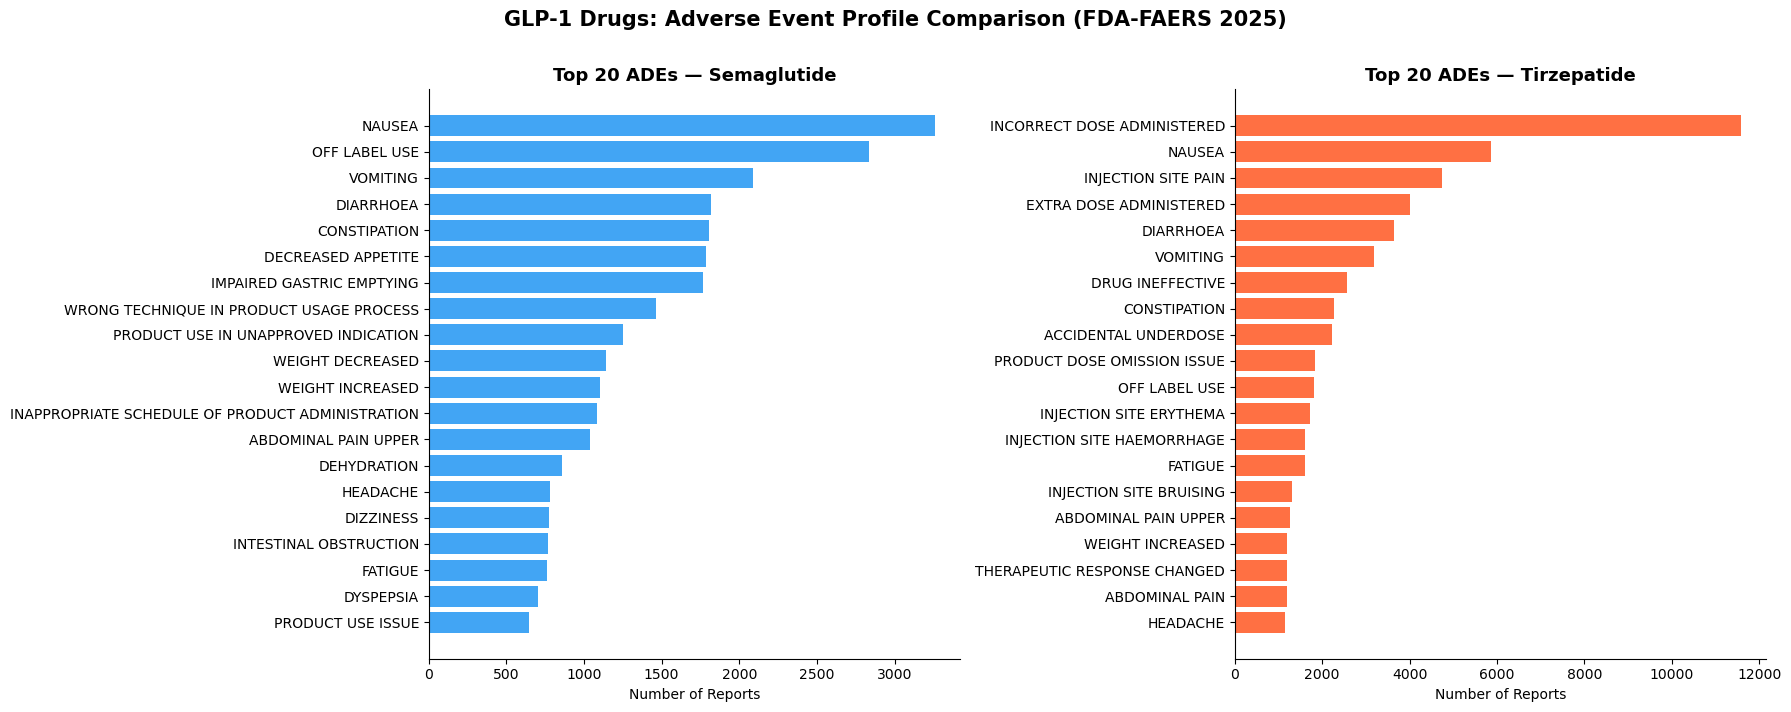

✅ Plot saved!


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, group, color in zip(axes, ['Semaglutide', 'Tirzepatide'], ['#2196F3', '#FF5722']):
    top = glp1_reac[glp1_reac['drug_group'] == group]['pt'].value_counts().head(20)
    ax.barh(top.index[::-1], top.values[::-1], color=color, alpha=0.85)
    ax.set_title(f'Top 20 ADEs — {group}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Reports')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('GLP-1 Drugs: Adverse Event Profile Comparison (FDA-FAERS 2025)', 
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('glp1_ade_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

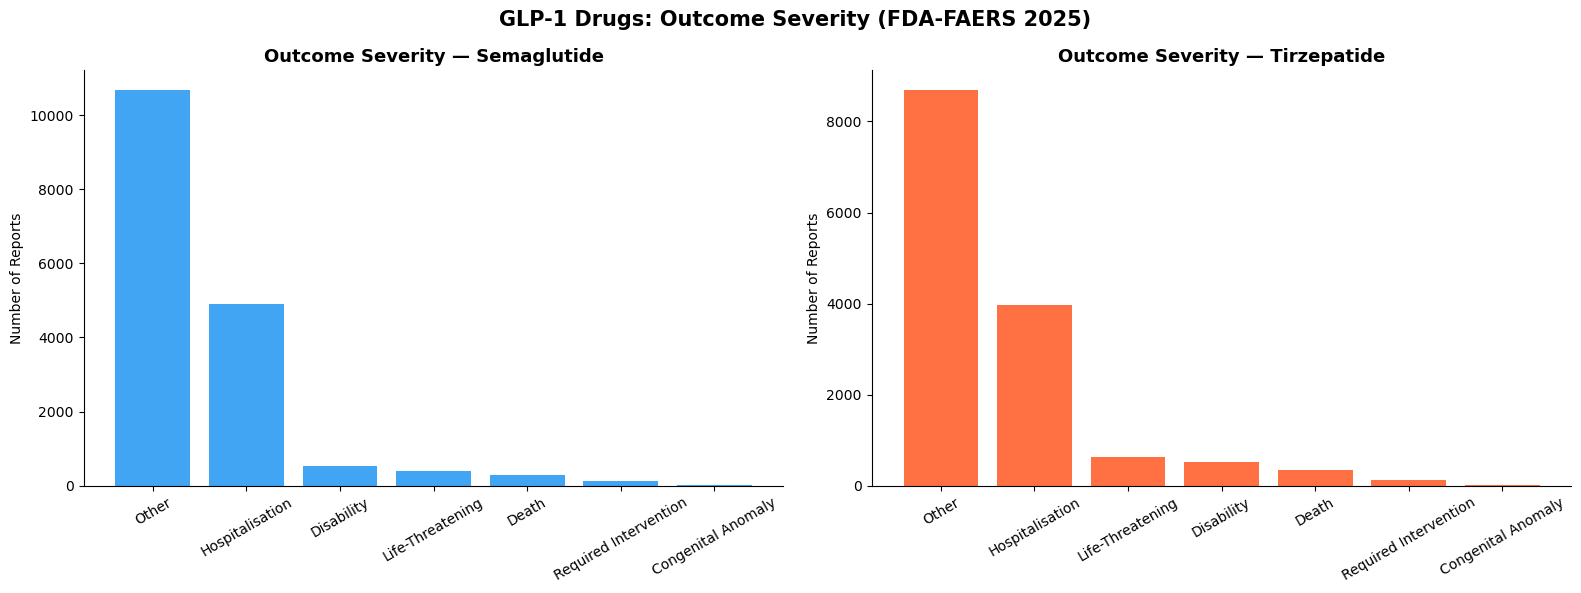

✅ Plot saved!


In [9]:
# Outcome codes meaning
outc_map = {
    'DE': 'Death',
    'LT': 'Life-Threatening',
    'HO': 'Hospitalisation',
    'DS': 'Disability',
    'CA': 'Congenital Anomaly',
    'RI': 'Required Intervention',
    'OT': 'Other'
}

glp1_outc['outcome_label'] = glp1_outc['outc_cod'].map(outc_map)

# Merge drug group
glp1_outc = glp1_outc.merge(
    glp1_drugs[['primaryid', 'drug_group']].drop_duplicates('primaryid'),
    on='primaryid', how='left'
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, group, color in zip(axes, ['Semaglutide', 'Tirzepatide'], ['#2196F3', '#FF5722']):
    data = glp1_outc[glp1_outc['drug_group'] == group]['outcome_label'].value_counts()
    ax.bar(data.index, data.values, color=color, alpha=0.85)
    ax.set_title(f'Outcome Severity — {group}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Reports')
    ax.tick_params(axis='x', rotation=30)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('GLP-1 Drugs: Outcome Severity (FDA-FAERS 2025)', 
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('glp1_outcomes.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

In [10]:
from scipy.stats import chi2_contingency
import scipy.stats as stats

def compute_ror_prr(drug_ids, all_ids, reac_df, top_n=30):
    """
    Compute ROR and PRR for a drug group vs all other drugs
    drug_ids : primaryids of the drug of interest
    all_ids  : all primaryids in the full dataset
    """
    other_ids = set(all_ids) - set(drug_ids)
    results = []

    # Get ADE counts for drug group
    drug_reac = reac_df[reac_df['primaryid'].isin(drug_ids)]['pt'].value_counts()
    
    # Get top ADEs to test
    top_ades = drug_reac.head(top_n).index.tolist()
    
    total_drug   = len(drug_ids)
    total_other  = len(other_ids)

    for ade in top_ades:
        a = reac_df[(reac_df['primaryid'].isin(drug_ids))   & (reac_df['pt'] == ade)].shape[0]
        c = reac_df[(reac_df['primaryid'].isin(other_ids))  & (reac_df['pt'] == ade)].shape[0]
        b = total_drug  - a
        d = total_other - c

        if b == 0 or c == 0 or d == 0:
            continue

        # PRR
        prr = (a / (a + b)) / (c / (c + d))
        
        # ROR
        ror = (a / b) / (c / d)
        ror_log = np.log(ror)
        se_log  = np.sqrt(1/a + 1/b + 1/c + 1/d)
        ror_lo  = np.exp(ror_log - 1.96 * se_log)
        ror_hi  = np.exp(ror_log + 1.96 * se_log)

        # Chi-square
        table = [[a, b], [c, d]]
        chi2, p_val, _, _ = chi2_contingency(table)

        # Signal = PRR≥2, Chi2≥4, n≥3
        signal = (prr >= 2) and (chi2 >= 4) and (a >= 3)

        results.append({
            'ADE': ade, 'n': a,
            'PRR': round(prr, 2),
            'ROR': round(ror, 2),
            'ROR_95CI_low': round(ror_lo, 2),
            'ROR_95CI_high': round(ror_hi, 2),
            'Chi2': round(chi2, 2),
            'p_value': round(p_val, 4),
            'SIGNAL': '🚨 YES' if signal else 'No'
        })

    return pd.DataFrame(results).sort_values('ROR', ascending=False)

# All case IDs in dataset
all_case_ids = demo_all['primaryid'].unique()

# Run for Semaglutide
sema_ids = glp1_drugs[glp1_drugs['drug_group'] == 'Semaglutide']['primaryid'].unique()
tirz_ids = glp1_drugs[glp1_drugs['drug_group'] == 'Tirzepatide']['primaryid'].unique()

print("⏳ Computing signals... (may take ~30 seconds)")
sema_signals = compute_ror_prr(sema_ids, all_case_ids, reac_all, top_n=40)
tirz_signals = compute_ror_prr(tirz_ids, all_case_ids, reac_all, top_n=40)

print("\n🚨 SEMAGLUTIDE — Top Signals:")
print(sema_signals[sema_signals['SIGNAL'] == '🚨 YES'][['ADE','n','PRR','ROR','ROR_95CI_low','ROR_95CI_high','Chi2']].to_string(index=False))

print("\n🚨 TIRZEPATIDE — Top Signals:")
print(tirz_signals[tirz_signals['SIGNAL'] == '🚨 YES'][['ADE','n','PRR','ROR','ROR_95CI_low','ROR_95CI_high','Chi2']].to_string(index=False))

⏳ Computing signals... (may take ~30 seconds)

🚨 SEMAGLUTIDE — Top Signals:
                                             ADE    n    PRR    ROR  ROR_95CI_low  ROR_95CI_high     Chi2
                                WEIGHT LOSS POOR  464 178.95 182.64        153.74         216.98 23000.05
                      OPTIC ISCHAEMIC NEUROPATHY  437 122.51 124.88        106.83         145.99 19080.47
                       IMPAIRED GASTRIC EMPTYING 1767  47.63  51.53         48.44          54.83 48047.64
                                           ILEUS  436  27.08  27.59         24.68          30.84  7878.35
                                          HUNGER  499  23.41  23.91         21.59          26.48  8009.34
                              INCREASED APPETITE  440  17.54  17.87         16.08          19.85  5479.08
                          INTESTINAL OBSTRUCTION  765  13.57  14.01         12.95          15.16  7471.29
                              EMOTIONAL DISTRESS  453   8.82   8.97         

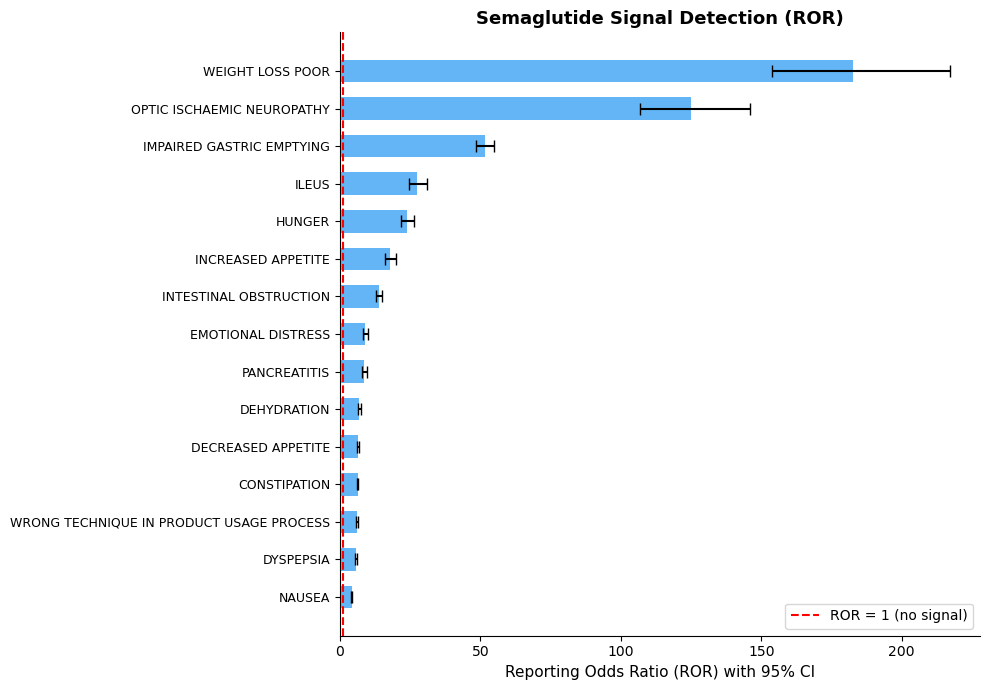

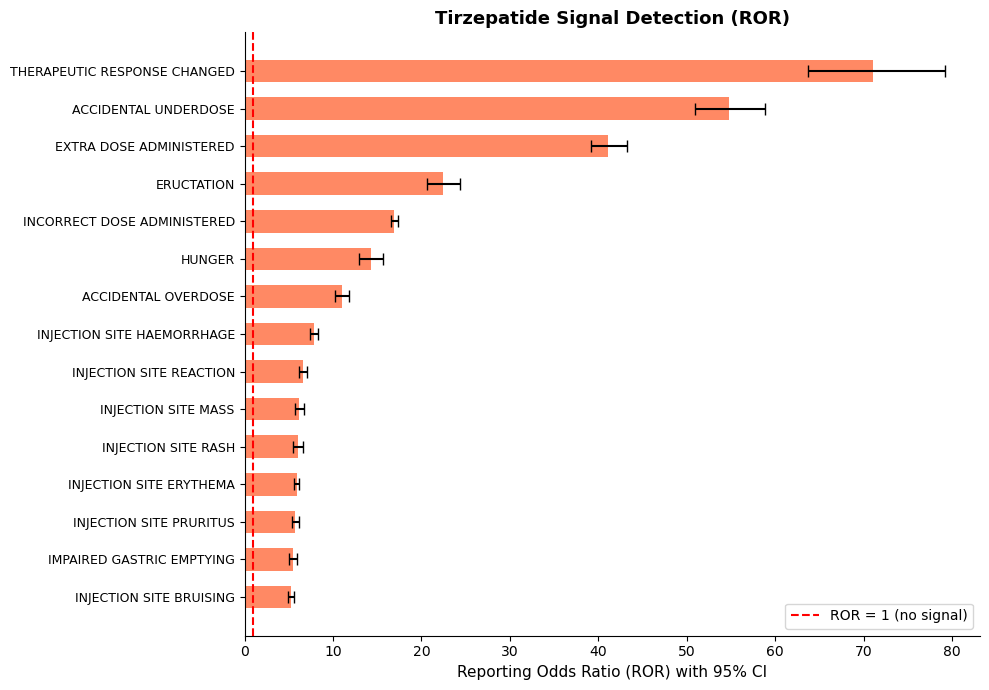

✅ Forest plots saved!


In [11]:
def plot_forest(df, title, color):
    sig = df[df['SIGNAL'] == '🚨 YES'].head(15).sort_values('ROR')
    
    fig, ax = plt.subplots(figsize=(10, 7))
    y_pos = range(len(sig))
    
    ax.barh(y_pos, sig['ROR'], xerr=[sig['ROR'] - sig['ROR_95CI_low'],
                                      sig['ROR_95CI_high'] - sig['ROR']],
            align='center', color=color, alpha=0.7, capsize=4, height=0.6)
    
    ax.axvline(x=1, color='red', linestyle='--', linewidth=1.5, label='ROR = 1 (no signal)')
    ax.set_yticks(list(y_pos))
    ax.set_yticklabels(sig['ADE'], fontsize=9)
    ax.set_xlabel('Reporting Odds Ratio (ROR) with 95% CI', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(f'{title[:10]}_forest.png', dpi=150)
    plt.show()

plot_forest(sema_signals, 'Semaglutide Signal Detection (ROR)', '#2196F3')
plot_forest(tirz_signals, 'Tirzepatide Signal Detection (ROR)', '#FF5722')
print("✅ Forest plots saved!")

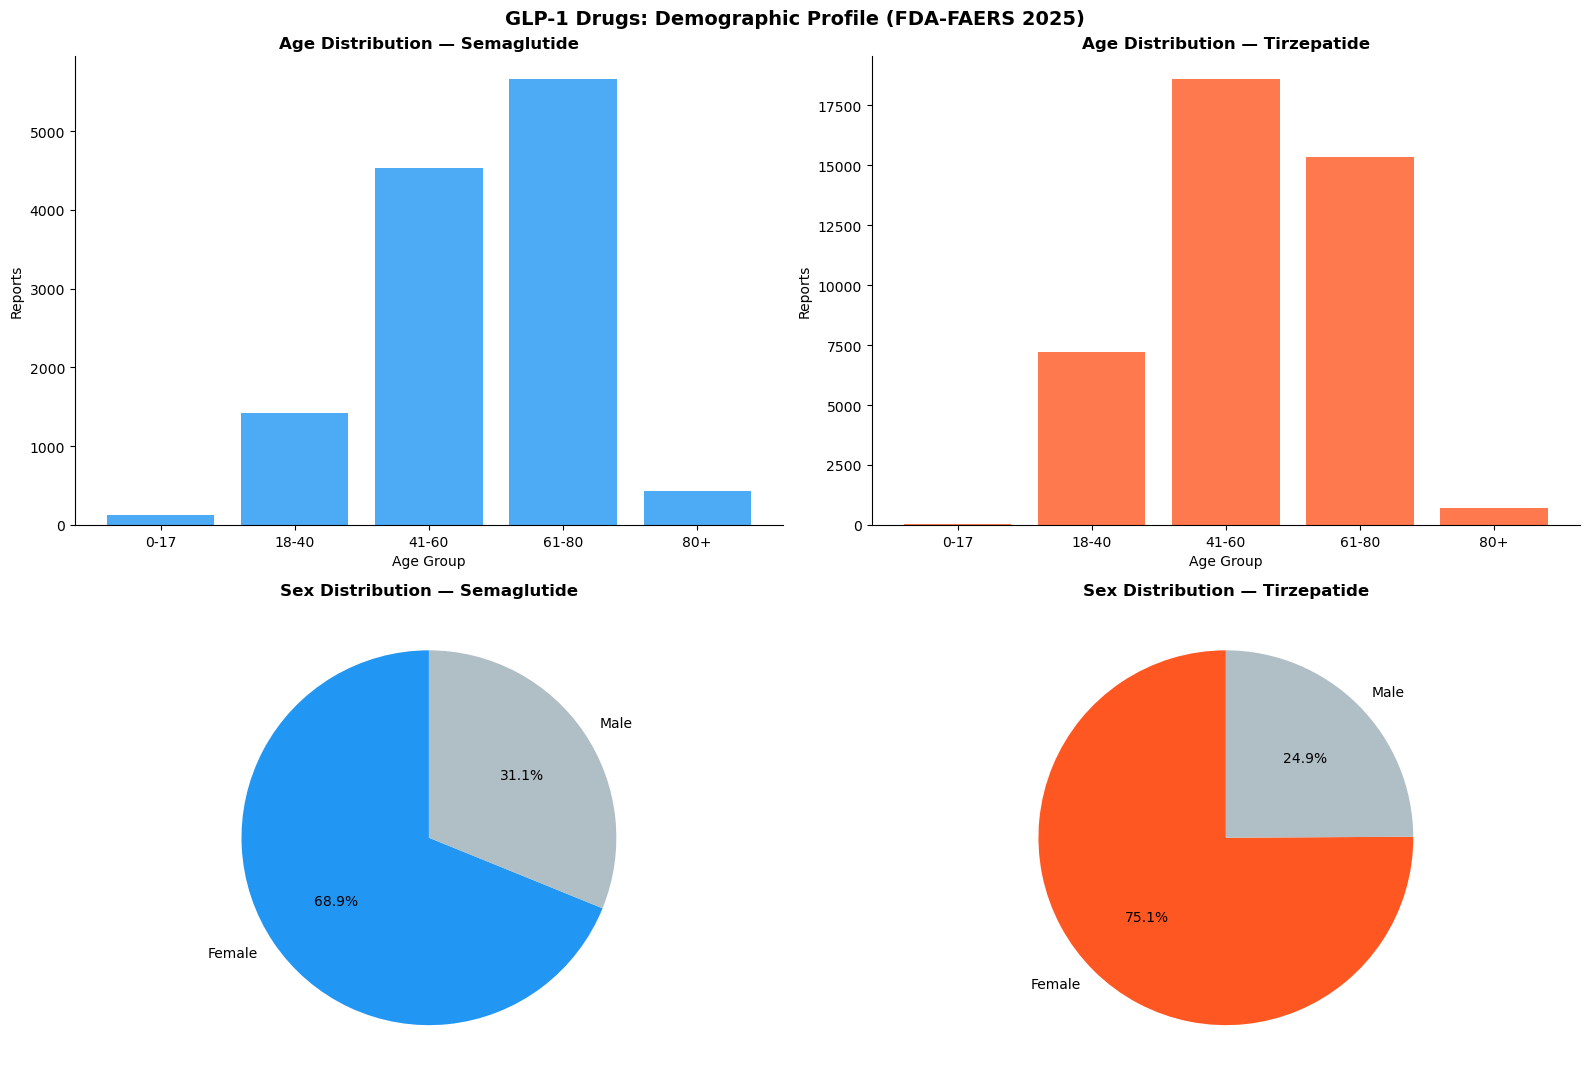

✅ Demographics plot saved!


In [12]:
# Merge demographics into GLP-1 cases
glp1_demo = demo_all[demo_all['primaryid'].isin(glp1_ids)].copy()
glp1_demo = glp1_demo.merge(
    glp1_drugs[['primaryid','drug_group']].drop_duplicates('primaryid'),
    on='primaryid', how='left'
)

# Clean age
glp1_demo['age_grp'] = pd.cut(
    pd.to_numeric(glp1_demo['age'], errors='coerce'),
    bins=[0,17,40,60,80,120],
    labels=['0-17','18-40','41-60','61-80','80+']
)

# Clean sex
glp1_demo['sex'] = glp1_demo['sex'].replace({
    'M':'Male','F':'Female','UNK':np.nan,
    'NS':np.nan, 0:np.nan
})

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Age distribution by group
for ax, group, color in zip([axes[0,0], axes[0,1]],
                             ['Semaglutide','Tirzepatide'],
                             ['#2196F3','#FF5722']):
    data = glp1_demo[glp1_demo['drug_group']==group]['age_grp'].value_counts().sort_index()
    ax.bar(data.index, data.values, color=color, alpha=0.8)
    ax.set_title(f'Age Distribution — {group}', fontweight='bold')
    ax.set_xlabel('Age Group'); ax.set_ylabel('Reports')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Sex distribution
sex_sema = glp1_demo[glp1_demo['drug_group']=='Semaglutide']['sex'].value_counts()
sex_tirz = glp1_demo[glp1_demo['drug_group']=='Tirzepatide']['sex'].value_counts()

for ax, data, group, color in zip([axes[1,0], axes[1,1]],
                                    [sex_sema, sex_tirz],
                                    ['Semaglutide','Tirzepatide'],
                                    ['#2196F3','#FF5722']):
    ax.pie(data.values, labels=data.index, autopct='%1.1f%%',
           colors=[color, '#B0BEC5'], startangle=90)
    ax.set_title(f'Sex Distribution — {group}', fontweight='bold')

plt.suptitle('GLP-1 Drugs: Demographic Profile (FDA-FAERS 2025)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('glp1_demographics.png', dpi=150)
plt.show()
print("✅ Demographics plot saved!")

In [14]:
# Key ADEs to track over time
track_ades = ['NAUSEA', 'IMPAIRED GASTRIC EMPTYING',
              'PANCREATITIS', 'OPTIC ISCHAEMIC NEUROPATHY',
              'INCORRECT DOSE ADMINISTERED']

# Check what columns glp1_reac already has
print("glp1_reac columns:", glp1_reac.columns.tolist())

# glp1_reac already has 'quarter' from when we loaded it — use it directly
# Just merge drug_group in if not already there
if 'drug_group' not in glp1_reac.columns:
    glp1_reac = glp1_reac.merge(
        glp1_drugs[['primaryid','drug_group']].drop_duplicates('primaryid'),
        on='primaryid', how='left'
    )

# Use the 'quarter' column already in glp1_reac (from the loading step)
glp1_reac_q = glp1_reac.copy()

print("Quarters present:", glp1_reac_q['quarter'].unique())
print("drug_group present:", glp1_reac_q['drug_group'].unique())

glp1_reac columns: ['primaryid', 'caseid', 'pt', 'drug_rec_act', 'quarter', 'drug_group', 'drugname']
Quarters present: ['25Q1' '25Q2' '25Q3' '25Q4']
drug_group present: ['Semaglutide' 'Tirzepatide']


Quarter order used: ['25Q1', '25Q2', '25Q3', '25Q4']


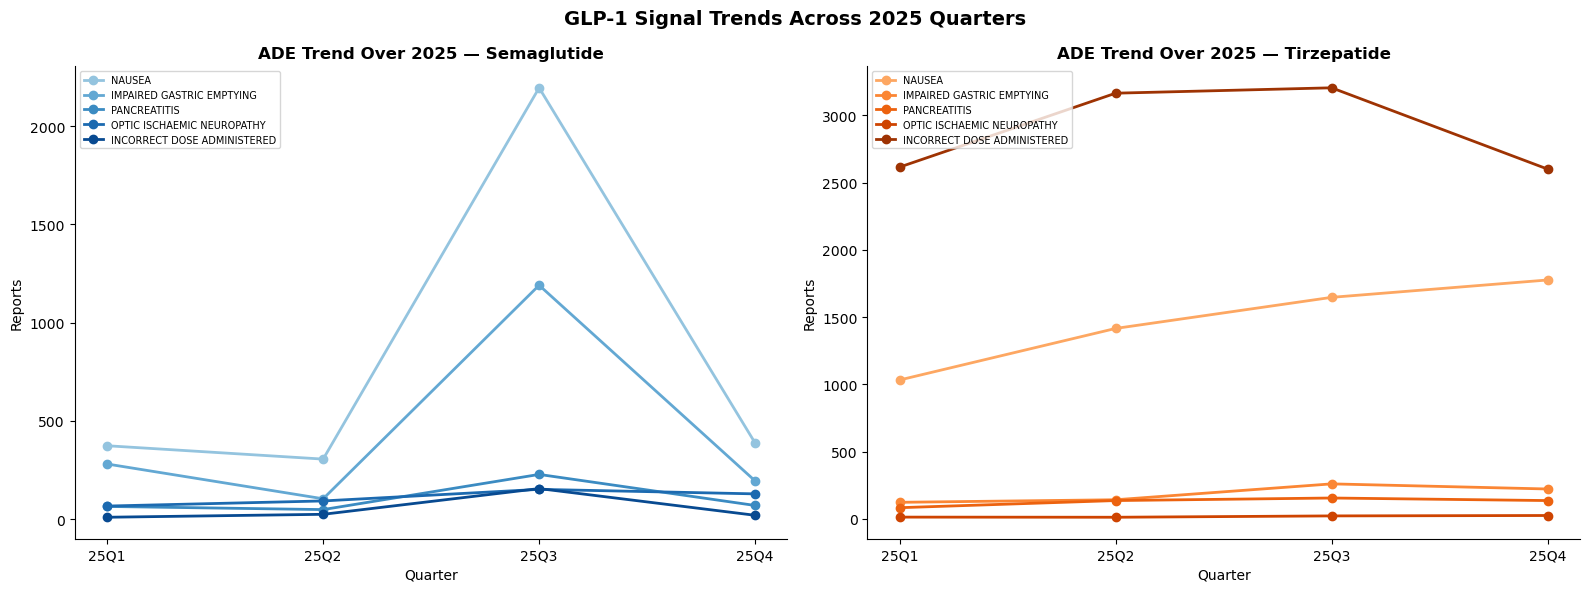

✅ Trend plot saved!


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Match whatever quarter labels exist in your data
quarter_order = sorted(glp1_reac_q['quarter'].dropna().unique().tolist())
print("Quarter order used:", quarter_order)

for ax, group, color_base in zip(axes,
                                  ['Semaglutide', 'Tirzepatide'],
                                  ['Blues', 'Oranges']):
    subset = glp1_reac_q[glp1_reac_q['drug_group'] == group]
    colors = plt.cm.get_cmap(color_base)(np.linspace(0.4, 0.9, len(track_ades)))

    for ade, col in zip(track_ades, colors):
        counts = (subset[subset['pt'] == ade]
                  .groupby('quarter')
                  .size()
                  .reindex(quarter_order, fill_value=0))
        ax.plot(quarter_order, counts.values, marker='o',
                label=ade, color=col, linewidth=2)

    ax.set_title(f'ADE Trend Over 2025 — {group}', fontweight='bold')
    ax.set_xlabel('Quarter')
    ax.set_ylabel('Reports')
    ax.legend(fontsize=7, loc='upper left')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('GLP-1 Signal Trends Across 2025 Quarters',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('glp1_trends.png', dpi=150)
plt.show()
print("✅ Trend plot saved!")

In [16]:
# Save all results to a single Excel file
output_path = os.path.join(base, 'GLP1_FAERS_Results.xlsx')

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    sema_signals.to_excel(writer, sheet_name='Semaglutide_Signals', index=False)
    tirz_signals.to_excel(writer, sheet_name='Tirzepatide_Signals', index=False)
    glp1_reac['pt'].value_counts().reset_index().to_excel(
        writer, sheet_name='All_GLP1_ADEs', index=False)
    glp1_outc['outcome_label'].value_counts().reset_index().to_excel(
        writer, sheet_name='Outcomes', index=False)
    glp1_demo['age_grp'].value_counts().reset_index().to_excel(
        writer, sheet_name='Demographics', index=False)

print(f"✅ Excel report saved to:\n   {output_path}")
print("\n🎉 ANALYSIS COMPLETE!")
print("   Plots saved: top_drugs_reactions.png, glp1_ade_comparison.png,")
print("                glp1_outcomes.png, Semaglutide_forest.png,")
print("                Tirzepatide_forest.png, glp1_demographics.png, glp1_trends.png")

✅ Excel report saved to:
   C:\Users\SAHASRAKSHI\Downloads\FDA-FAERS analysis\GLP1_FAERS_Results.xlsx

🎉 ANALYSIS COMPLETE!
   Plots saved: top_drugs_reactions.png, glp1_ade_comparison.png,
                glp1_outcomes.png, Semaglutide_forest.png,
                Tirzepatide_forest.png, glp1_demographics.png, glp1_trends.png
